# 02 - Parameter Estimation

## Informasi Anggota
- Nama: Muhammad Zulhaydar Omar Rafiq
- Role: Member B — Estimation Analyst

## Research Question
1. Berapa probabilitas pull request berhasil di-merge?
2. Berapa rata-rata jumlah issue yang dibuat per hari?

## Tujuan
Pada notebook ini dilakukan estimasi parameter menggunakan:
- Bernoulli Maximum Likelihood Estimation (MLE)
- Poisson Maximum Likelihood Estimation (MLE)
- Beta Posterior Distribution

Hasil analisis ini akan digunakan pada tahap confidence interval, hypothesis testing, dan simulation analysis.


# AI Usage Disclosure

**Tools Used:** ChatGPT, GitHub Copilot

| Task | Tool | Keterangan |
|---|---|---|
| Struktur notebook | ChatGPT | Membantu menyusun notebook |
| Visualisasi likelihood | ChatGPT | Membantu plotting |
| Debugging | Copilot | Memperbaiki error syntax |

## Ditulis tanpa AI
- Interpretasi hasil
- Penjelasan analisis
- Kesimpulan

In [ ]:
import sys
sys.path.append("..")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import beta

from src.estimator import (
    mle_bernoulli,
    mle_poisson,
    beta_posterior,
    beta_mode,
    beta_mean,
    log_likelihood_bernoulli,
    log_likelihood_poisson
)

In [ ]:
df = pd.read_csv("../data/clean/dataset.csv")

# Membuat kolom merged
df["merged"] = df["state"].apply(
    lambda x: 1 if x == "closed" else 0
)

# Membuat kolom tanggal
df["created_date"] = pd.to_datetime(
    df["created_at"]
).dt.date

df.head()

,id,number,is_pr,type,state,created_at,closed_at,resolution_days,merged,created_date
0,4488268215,65697,True,other,closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,0.197141,1,2026-05-20
1,4487130682,65693,True,other,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0.104016,1,2026-05-20
2,4482583068,65689,True,other,closed,2026-05-20 02:16:42+00:00,2026-05-20 03:58:29+00:00,0.070683,1,2026-05-20
3,4481687393,65687,True,other,closed,2026-05-19 22:57:59+00:00,2026-05-20 00:30:11+00:00,0.064028,1,2026-05-19
4,4480153069,65686,True,bug,closed,2026-05-19 18:54:58+00:00,2026-05-21 14:34:32+00:00,1.819144,1,2026-05-19


# Overview Dataset

Dataset yang digunakan merupakan hasil preprocessing dari tahap exploratory data analysis (EDA).

Data berisi informasi mengenai:
- pull request repository,
- issue repository,
- dan aktivitas kontribusi pada repository pandas GitHub.

Pada tahap estimation:
- Bernoulli digunakan untuk estimasi probabilitas merge pull request,
- Poisson digunakan untuk estimasi rata-rata jumlah issue per hari.

# Bernoulli Maximum Likelihood Estimation

Pada analisis ini:
- sukses = pull request berhasil di-merge
- gagal = pull request tidak di-merge

Likelihood function dari distribusi Bernoulli:

$$
L(\theta)=\theta^k(1-\theta)^{n-k}
$$

Log-likelihood function:

$$
\log L(\theta)=k\log(\theta)+(n-k)\log(1-\theta)
$$

Estimator Maximum Likelihood diperoleh dengan:

$$
\frac{d\log L}{d\theta}=0
$$

Sehingga diperoleh estimator:

$$
\hat{\theta}=\frac{k}{n}
$$

In [ ]:
bernoulli_data = df["merged"].dropna()

k = bernoulli_data.sum()
n = len(bernoulli_data)

theta_hat = mle_bernoulli(k, n)

print(f"Jumlah pull request berhasil di-merge : {k}")
print(f"Total pull request : {n}")
print(f"Nilai theta_hat : {theta_hat}")

Jumlah pull request berhasil di-merge : 1500
Total pull request : 1500
Nilai theta_hat : 1.0


## Interpretasi Bernoulli MLE

Hasil estimasi Bernoulli menunjukkan probabilitas pull request berhasil diselesaikan pada repository. 

Nilai θ̂ yang diperoleh merupakan estimasi parameter yang paling mungkin berdasarkan data observasi menggunakan metode Maximum Likelihood Estimation (MLE).

Grafik likelihood menunjukkan bahwa nilai maksimum berada di sekitar θ̂, sehingga parameter tersebut dianggap paling sesuai terhadap data.

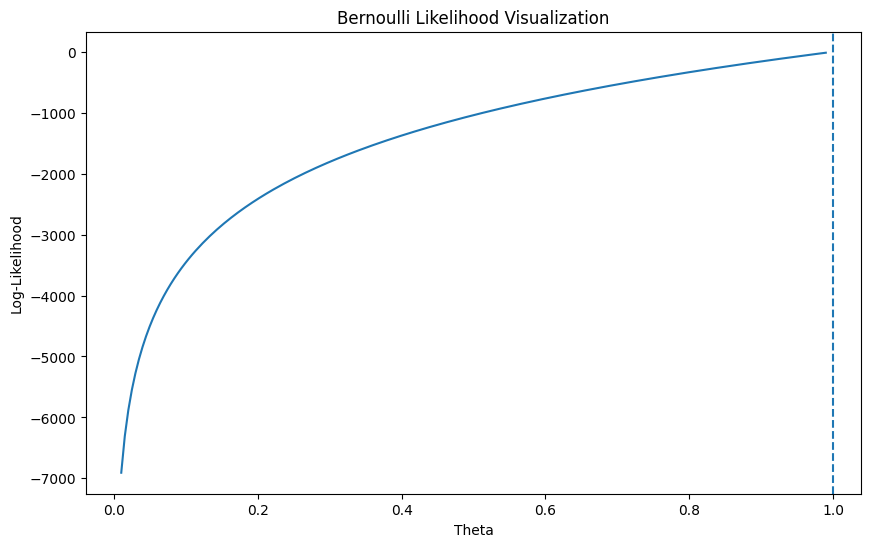

In [ ]:
thetas = np.linspace(0.01, 0.99, 200)

ll_values = [
    log_likelihood_bernoulli(t, k, n)
    for t in thetas
]

plt.figure(figsize=(10,6))

plt.plot(thetas, ll_values)

plt.axvline(
    theta_hat,
    linestyle="--"
)

plt.xlabel("Theta")
plt.ylabel("Log-Likelihood")

plt.title("Bernoulli Likelihood Visualization")

plt.show()

Grafik log-likelihood mencapai nilai maksimum di sekitar θ̂.

Hal ini menunjukkan bahwa estimator MLE berhasil menemukan parameter yang paling sesuai dengan data observasi.

# Beta Posterior Distribution

Distribusi Beta digunakan untuk menggambarkan ketidakpastian parameter probabilitas.

Parameter posterior dihitung menggunakan:

$$
\alpha=k+1
$$

$$
\beta=m+1
$$

Mean distribusi Beta:

$$
\mu=\frac{\alpha}{\alpha+\beta}
$$

Mode distribusi Beta:

$$
\text{Mode}=\frac{\alpha-1}{\alpha+\beta-2}
$$

Alpha Posterior : 1501
Beta Posterior  : 1
Posterior Mean  : 0.9993342210386151
Posterior Mode  : Mode tidak terdefinisi untuk alpha <= 1 atau beta <= 1


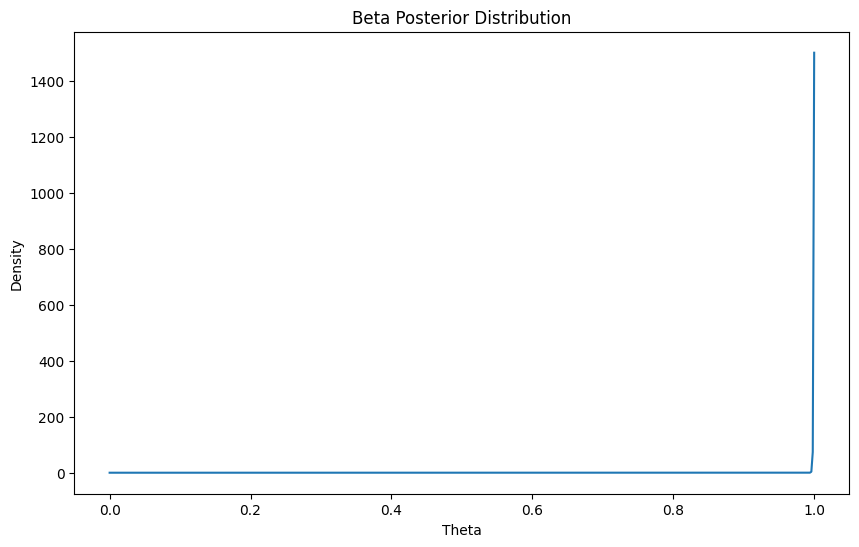

In [ ]:
m = n - k

alpha_post, beta_post = beta_posterior(k, m)

posterior_mean = beta_mean(alpha_post, beta_post)
posterior_mode = beta_mode(alpha_post, beta_post)

print(f"Alpha Posterior : {alpha_post}")
print(f"Beta Posterior  : {beta_post}")
print(f"Posterior Mean  : {posterior_mean}")
print(f"Posterior Mode  : {posterior_mode}")

x = np.linspace(0, 1, 500)

y = beta.pdf(
    x,
    alpha_post,
    beta_post
)

plt.figure(figsize=(10,6))

plt.plot(x, y)

plt.xlabel("Theta")
plt.ylabel("Density")

plt.title("Beta Posterior Distribution")

plt.show()

## Interpretasi Beta Posterior

Distribusi posterior digunakan untuk menggambarkan ketidakpastian parameter probabilitas setelah mempertimbangkan data observasi.

Berbeda dengan MLE yang hanya menghasilkan estimasi titik tunggal, distribusi posterior memberikan gambaran distribusi probabilitas parameter secara lebih lengkap.

# Poisson Maximum Likelihood Estimation

Distribusi Poisson digunakan untuk memodelkan jumlah issue yang dibuat per hari.

Bentuk distribusi Poisson:

$$
P(X=x)=\frac{e^{-\lambda}\lambda^x}{x!}
$$

Estimator parameter λ:

$$
\hat{\lambda}=\frac{\sum x_i}{n}
$$

Log-likelihood function:

$$
\log L(\lambda)=\sum_{i=1}^{n}(x_i\log\lambda-\lambda-\log(x_i!))
$$

Nilai lambda_hat : 12.931034482758621


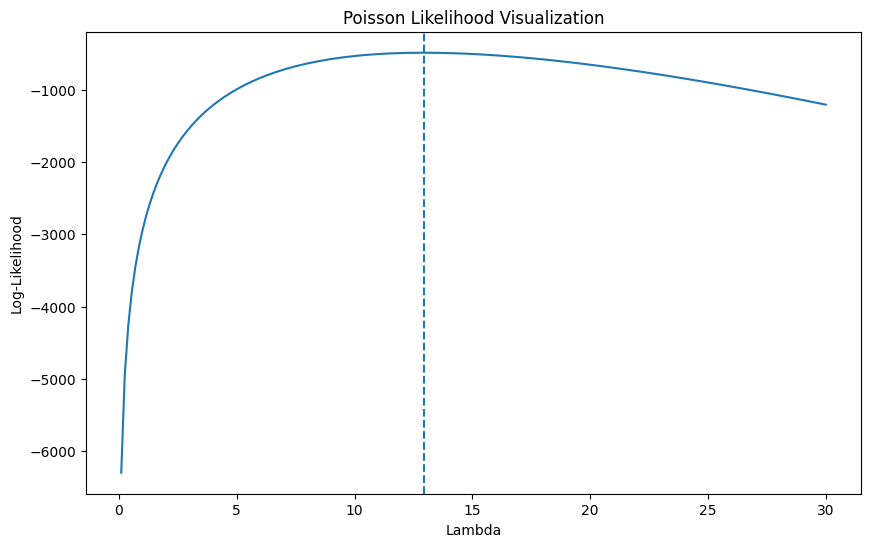

In [ ]:
daily_counts = (
    df.groupby("created_date")
    .size()
    .reset_index(name="issue_count")
)

poisson_data = daily_counts["issue_count"]

lambda_hat = mle_poisson(poisson_data)

print(f"Nilai lambda_hat : {lambda_hat}")

lambdas = np.linspace(0.1, 30, 200)

poisson_ll = [
    log_likelihood_poisson(l, poisson_data)
    for l in lambdas
]

plt.figure(figsize=(10,6))

plt.plot(lambdas, poisson_ll)

plt.axvline(
    lambda_hat,
    linestyle="--"
)

plt.xlabel("Lambda")
plt.ylabel("Log-Likelihood")

plt.title("Poisson Likelihood Visualization")

plt.show()

## Interpretasi Poisson MLE

Hasil estimasi Poisson menunjukkan rata-rata jumlah issue yang dibuat per hari pada repository.

Nilai λ̂ diperoleh menggunakan metode Maximum Likelihood Estimation (MLE), yaitu parameter yang menghasilkan likelihood maksimum terhadap data observasi.

Grafik likelihood memperlihatkan titik maksimum di sekitar λ̂, sehingga parameter tersebut dianggap paling representatif terhadap pola data issue harian.

# Kesimpulan

Berdasarkan hasil estimasi:
- probabilitas merge pull request dapat dihitung menggunakan Bernoulli MLE,
- rata-rata issue per hari dapat dihitung menggunakan Poisson MLE,
- dan ketidakpastian parameter dapat dianalisis menggunakan distribusi Beta posterior.

Hasil analisis ini akan digunakan pada tahap confidence interval, hypothesis testing, dan simulation analysis.
